In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np

file_path = r"/content/drive/MyDrive/AYP/Diabetes.csv"
data = pd.read_csv(file_path)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,120,72,22,56,20.8,0.733,48,0
1,1,71,62,0,0,21.8,0.416,26,0
2,8,74,70,40,49,35.3,0.705,39,0
3,5,88,78,30,0,27.6,0.258,37,0
4,10,115,98,0,0,24.0,1.022,34,0
...,...,...,...,...,...,...,...,...,...
303,10,101,76,48,180,32.9,0.171,63,0
304,2,122,70,27,0,36.8,0.340,27,0
305,5,121,72,23,112,26.2,0.245,30,0
306,1,126,60,0,0,30.1,0.349,47,1


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               308 non-null    int64  
 1   Glucose                   308 non-null    int64  
 2   BloodPressure             308 non-null    int64  
 3   SkinThickness             308 non-null    int64  
 4   Insulin                   308 non-null    int64  
 5   BMI                       308 non-null    float64
 6   DiabetesPedigreeFunction  308 non-null    float64
 7   Age                       308 non-null    int64  
 8   Outcome                   308 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.8 KB


In [9]:
data.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
data.drop(['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin','DiabetesPedigreeFunction', 'Outcome'], axis = 1, inplace = True)

In [11]:
data.columns

Index(['Glucose', 'BMI', 'Age'], dtype='object')

In [12]:
data = data.rename(columns={"BMI": "IMC"})

In [13]:
data[data["IMC"] < 0]

,Glucose,IMC,Age


In [14]:
data

,Glucose,IMC,Age
0,120,20.8,48
1,71,21.8,26
2,74,35.3,39
3,88,27.6,37
4,115,24.0,34
...,...,...,...
303,101,32.9,63
304,122,36.8,27
305,121,26.2,30
306,126,30.1,47


          Glucose       IMC       Age
Glucose  1.000000  0.195295  0.225663
IMC      0.195295  1.000000 -0.004538
Age      0.225663 -0.004538  1.000000


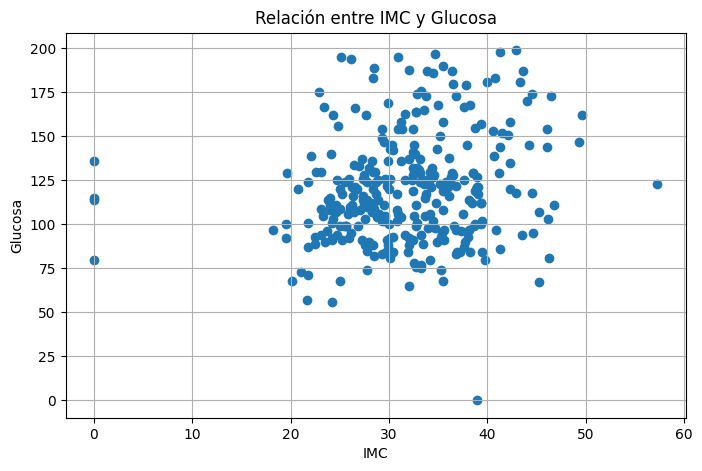

In [15]:
import matplotlib.pyplot as plt

# Correlación entre variables
print(data.corr())

# Gráfica IMC vs Glucosa
plt.figure(figsize=(8,5))

plt.scatter(data["IMC"], data["Glucose"])

plt.xlabel("IMC")
plt.ylabel("Glucosa")
plt.title("Relación entre IMC y Glucosa")

plt.grid(True)

plt.show()

In [16]:
#Clasificacion imc
def clasif_imc(IMC):
  if IMC < 25:
    return "normal"
  elif IMC < 30:
    return "sobrepeso"
  else:
    return "obesidad"


In [17]:
data["Tipo de peso"] = data["IMC"].apply(clasif_imc)

In [18]:
data

,Glucose,IMC,Age,Tipo de peso
0,120,20.8,48,normal
1,71,21.8,26,normal
2,74,35.3,39,obesidad
3,88,27.6,37,sobrepeso
4,115,24.0,34,normal
...,...,...,...,...
303,101,32.9,63,obesidad
304,122,36.8,27,obesidad
305,121,26.2,30,sobrepeso
306,126,30.1,47,obesidad


In [19]:
data

,Glucose,IMC,Age,Tipo de peso
0,120,20.8,48,normal
1,71,21.8,26,normal
2,74,35.3,39,obesidad
3,88,27.6,37,sobrepeso
4,115,24.0,34,normal
...,...,...,...,...
303,101,32.9,63,obesidad
304,122,36.8,27,obesidad
305,121,26.2,30,sobrepeso
306,126,30.1,47,obesidad


In [20]:
#mayores de 50 con sobrepeso
data[(data["Age"]>50)&(data['Tipo de peso']=="sobrepeso")]

,Glucose,IMC,Age,Tipo de peso
15,137,27.3,59,sobrepeso
19,132,28.0,63,sobrepeso
29,194,26.1,67,sobrepeso
35,166,26.6,66,sobrepeso
38,195,25.1,55,sobrepeso
49,120,25.0,64,sobrepeso
92,114,27.8,66,sobrepeso
97,110,27.8,58,sobrepeso
122,121,26.5,62,sobrepeso
124,124,28.7,52,sobrepeso


In [21]:
#promedio de glucosa por categoria de peso
promedio = data.groupby("Tipo de peso")["Glucose"].mean()

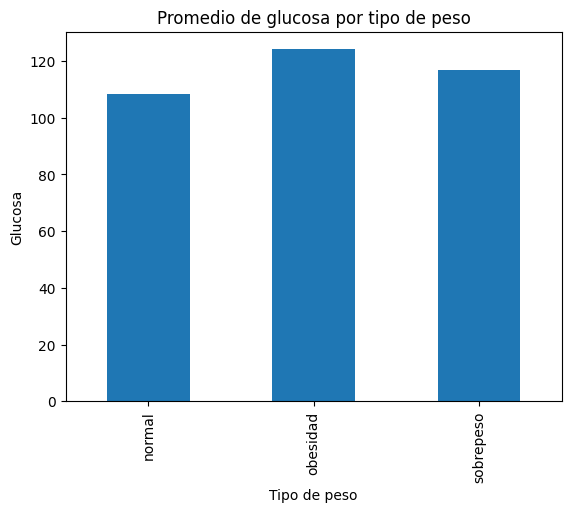

In [28]:
promedio.plot(kind="bar")
plt.title("Promedio de glucosa por tipo de peso")
plt.ylabel("Glucosa")
plt.show()

In [22]:
print(promedio)

Tipo de peso
normal       108.340909
obesidad     124.191257
sobrepeso    116.802469
Name: Glucose, dtype: float64


In [23]:
promedio_edad= data.groupby("Tipo de peso")["Age"].mean()

Text(0, 0.5, 'promedio_edad')

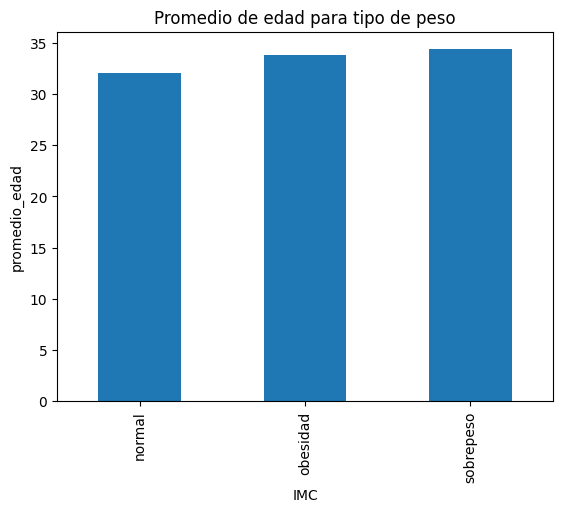

In [24]:
promedio_edad.plot(kind="bar")
plt.title("Promedio de edad para tipo de peso")
plt.xlabel("IMC")
plt.ylabel("promedio_edad")

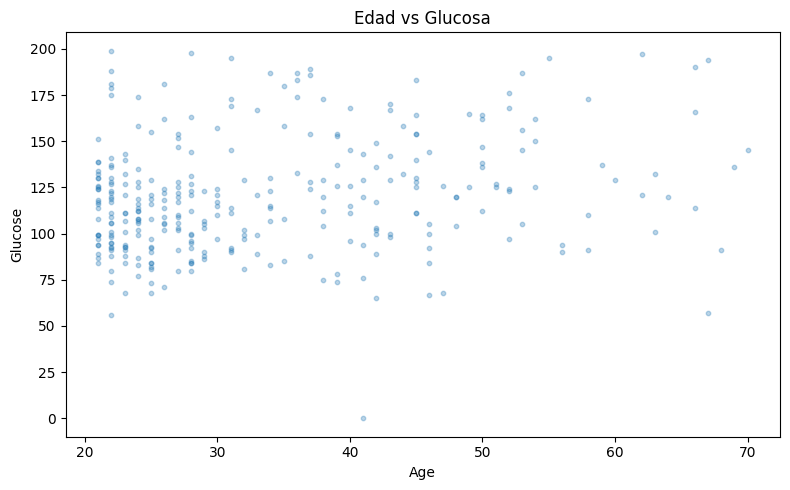

In [25]:
#relacion entre glucosa y edad
plt.figure(figsize=(8,5))
plt.scatter(data['Age'], data['Glucose'], s=10, alpha=0.3)
plt.title("Edad vs Glucosa")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.tight_layout()
plt.show()

In [26]:
data["Tipo de peso"].value_counts()

,count
Tipo de peso,
obesidad,183
sobrepeso,81
normal,44


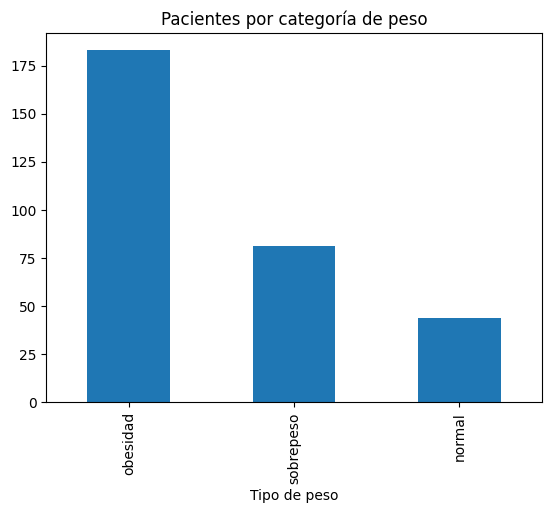

In [27]:
data["Tipo de peso"].value_counts().plot(kind="bar")
plt.title("Pacientes por categoría de peso")
plt.show()